# ClinicalNotes task generation

In [1]:
# General importations.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math
import string
from random import shuffle,seed,choices
from faker import Faker
from faker.providers.person.en import Provider
import networkx as nx
import itertools

from utils import Utils
from clinical_notes import ClinicalNotes
from dataset_generator import DataSetGenerator

In [2]:
u = Utils()
dg = DataSetGenerator()

## Error test (low complexity)

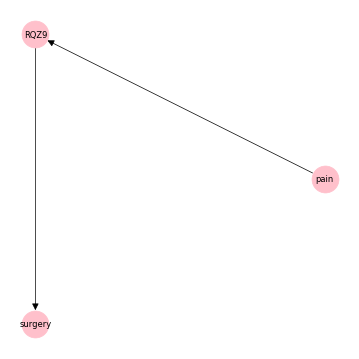


Context: Chronic disease H5VU54 sometimes requires surgical intervention, depending on genetics, patient history, vital signs, and lab results. The patient will experience significant pain (rated greater than or equal to 7/10) if they carry allele D5XA, a genetic marker for severe H5VU54. If the patient self-reports significant pain or the patient has a family history of PJ0A, then lab RQZ9 will be low (less than 3.04 mg/dL). If RQZ9 is low and the patient has previously received surgery for BZHZ, then the surgeon will recommend surgery. Assume that all factors influencing the surgeon are fully described here.

Patient history: Now, we will review the history and physical notes for patient Jennifer Harris. History of Present Illness: Jennifer Harris is a 66-year-old female with H5VU54 who presented to the emergency department with acute onset pain that began 5 hours prior to arrival. Pain was rated 4/10. The patient reports the pain has been persistent since onset. The patient took as

In [3]:
size = [2,2]
tg = ClinicalNotes(n_per_bcc = size, 
                   bcc_types = ["cycle"]*len(size))
context = tg.get_causal_context()
patient_history = tg.get_sample_context(n_extra_vars = 2)
print()
print("Context:", context)
print()
print("Patient history:", patient_history)
print()
print("- Global cause-effect pairs:", tg.get_global())
print("- Local cause-effect pairs:", tg.get_local())
print("- Compositions:", tg.get_compositions())
print("- Causal functions:", tg.causal_functions)

In [4]:
print()
print("- Factual queries:")
display(tg.get_factual_queries())


- Factual queries:


{'surgery': {'Prompt': 'Given these history and physical notes, will the surgeon recommend surgery? Begin your response with Yes or No and be as concise as possible.',
  'True endogenous': {'pain': 0, 'RQZ9': 1, 'surgery': 0},
  'True exogenous': {'D5XA': 0, 'PJ0A': 1, 'BZHZ': 0},
  'True response': 0},
 'RQZ9': {'Prompt': 'Given these history and physical notes, will lab RQZ9 be low? Begin your response with Yes or No and be as concise as possible.',
  'True endogenous': {'pain': 0, 'RQZ9': 1, 'surgery': 0},
  'True exogenous': {'D5XA': 0, 'PJ0A': 1, 'BZHZ': 0},
  'True response': 1}}

In [5]:
cf_1, cf_0 = tg.get_counterfactual_queries()
print("- Counterfactual queries (cause = True):")
for key,val in cf_1.items():
    print("\n-----------------------")
    print("\n-- {} --".format(key))
    print("Prompt:", val.get("Prompt"))
    print("True endogenous:", val.get("True endogenous"))
    print("True exogenous:", val.get("True exogenous"))
    print("True response:", val.get("True response"))
print("\n-----------------------")

- Counterfactual queries (cause = True):

-----------------------

-- ('pain', 'surgery') --
Prompt: Now suppose that the patient will be in significant pain regardless of all other circumstances. With this new assumption, will the surgeon recommend surgery? Begin your response with Yes or No and be as concise as possible.
True endogenous: {'pain': 1, 'RQZ9': 1, 'surgery': 0}
True exogenous: {'D5XA': 0, 'PJ0A': 1, 'BZHZ': 0}
True response: 0

-----------------------

-- ('pain', 'RQZ9') --
Prompt: Now suppose that the patient will be in significant pain regardless of all other circumstances. With this new assumption, will lab RQZ9 be low? Begin your response with Yes or No and be as concise as possible.
True endogenous: {'pain': 1, 'RQZ9': 1, 'surgery': 0}
True exogenous: {'D5XA': 0, 'PJ0A': 1, 'BZHZ': 0}
True response: 1

-----------------------

-- ('RQZ9', 'surgery') --
Prompt: Now suppose that lab RQZ9 will be low regardless of all other circumstances. With this new assumption, wil

In [6]:
print("- Counterfactual queries (cause = False):")
for key,val in cf_0.items():
    print("\n-----------------------")
    print("\n-- {} --".format(key))
    print("Prompt:", val.get("Prompt"))
    print("True endogenous:", val.get("True endogenous"))
    print("True exogenous:", val.get("True exogenous"))
    print("True response:", val.get("True response"))
print("\n-----------------------")

- Counterfactual queries (cause = False):

-----------------------

-- ('pain', 'surgery') --
Prompt: Now suppose that the patient will not be in pain regardless of all other circumstances. With this new assumption, will the surgeon recommend surgery? Begin your response with Yes or No and be as concise as possible.
True endogenous: {'pain': 0, 'RQZ9': 1, 'surgery': 0}
True exogenous: {'D5XA': 0, 'PJ0A': 1, 'BZHZ': 0}
True response: 0

-----------------------

-- ('pain', 'RQZ9') --
Prompt: Now suppose that the patient will not be in pain regardless of all other circumstances. With this new assumption, will lab RQZ9 be low? Begin your response with Yes or No and be as concise as possible.
True endogenous: {'pain': 0, 'RQZ9': 1, 'surgery': 0}
True exogenous: {'D5XA': 0, 'PJ0A': 1, 'BZHZ': 0}
True response: 1

-----------------------

-- ('RQZ9', 'surgery') --
Prompt: Now suppose that lab RQZ9 will not be low regardless of all other circumstances. With this new assumption, will the surge

In [7]:
# Test observational data generation.
df_obs, df_noise = tg.sample_scm(n = 5,
                                 intervene_node = None,
                                 intervene_value = 0)
display(df_obs.head())
display(df_noise.head())

,pain,RQZ9,surgery
0,1,1,1
1,1,1,0
2,1,1,1
3,1,1,0
4,1,1,1


,D5XA,PJ0A,BZHZ
0,1,1,1
1,1,1,0
2,1,1,1
3,1,1,0
4,1,1,1


In [8]:
# Test counterfactual data generation.
causes = set([x[0] for x in [tg.get_global()]+tg.get_local()])
intervene_value = 1
for cause in causes:
    print("\n-- {} = {} --".format(cause,intervene_value))
    df_obs, df_noise = tg.sample_scm(n = 5,
                                     intervene_node = cause,
                                     intervene_value = intervene_value)
    display(df_obs.head())
    display(df_noise.head())


-- RQZ9 = 1 --


,pain,RQZ9,surgery
0,1,1,1
1,1,1,0
2,1,1,1
3,1,1,0
4,1,1,1


,D5XA,PJ0A,BZHZ
0,1,1,1
1,1,1,0
2,1,1,1
3,1,1,0
4,1,1,1



-- pain = 1 --


,pain,RQZ9,surgery
0,1,1,1
1,1,1,0
2,1,1,1
3,1,1,0
4,1,1,1


,D5XA,PJ0A,BZHZ
0,1,1,1
1,1,1,0
2,1,1,1
3,1,1,0
4,1,1,1


In [9]:
# Test counterfactual data generation.
causes = set([x[0] for x in [tg.get_global()]+tg.get_local()])
intervene_value = 0
for cause in causes:
    print("\n-- {} = {} --".format(cause,intervene_value))
    df_obs, df_noise = tg.sample_scm(n = 5,
                                     intervene_node = cause,
                                     intervene_value = intervene_value)
    display(df_obs.head())
    display(df_noise.head())


-- RQZ9 = 0 --


,pain,RQZ9,surgery
0,1,0,0
1,1,0,0
2,1,0,0
3,1,0,0
4,1,0,0


,D5XA,PJ0A,BZHZ
0,1,1,1
1,1,1,0
2,1,1,1
3,1,1,0
4,1,1,1



-- pain = 0 --


,pain,RQZ9,surgery
0,0,1,1
1,0,1,0
2,0,1,1
3,0,1,0
4,0,1,1


,D5XA,PJ0A,BZHZ
0,1,1,1
1,1,1,0
2,1,1,1
3,1,1,0
4,1,1,1


## Error test (moderate complexity)

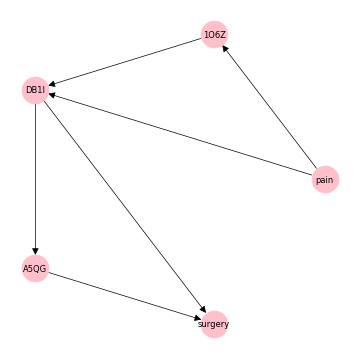


Context: Chronic disease C427BN sometimes requires surgical intervention, depending on genetics, patient history, vital signs, and lab results. The patient will experience significant pain (rated greater than or equal to 8/10) if they carry allele X727, a genetic marker for severe C427BN. If the patient self-reports significant pain or the patient carries allele Y2K5, then lab 1O6Z will be elevated (greater than 2.39 mg/dL). If the patient self-reports significant pain or 1O6Z is elevated or the patient has previously received surgery for O8T7, then lab DB1I will be low (less than 2.62 mg/dL). If DB1I is low or the patient has a family history of EDH6, then lab A5QG will be low (less than 2.46 mg/dL). If DB1I is low and A5QG is low and the patient carries allele U18E, then the surgeon will recommend surgery. Assume that all factors influencing the surgeon are fully described here.

Patient history: Now, we will review the history and physical notes for patient Brian Wilkins. History o

In [10]:
size = [3,3]
tg = ClinicalNotes(n_per_bcc = size, 
                   bcc_types = ["cycle"]*len(size))
context = tg.get_causal_context()
patient_history = tg.get_sample_context(n_extra_vars = 2)
print()
print("Context:", context)
print()
print("Patient history:", patient_history)
print()
print("- Global cause-effect pairs:", tg.get_global())
print("- Local cause-effect pairs:", tg.get_local())
print("- Compositions:", tg.get_compositions())
print("- Causal functions:", tg.causal_functions)

In [11]:
print()
print("- Factual queries:")
display(tg.get_factual_queries())


- Factual queries:


{'surgery': {'Prompt': 'Given these history and physical notes, will the surgeon recommend surgery? Begin your response with Yes or No and be as concise as possible.',
  'True endogenous': {'pain': 1,
   '1O6Z': 1,
   'DB1I': 1,
   'A5QG': 1,
   'surgery': 0},
  'True exogenous': {'X727': 1, 'Y2K5': 0, 'O8T7': 1, 'EDH6': 0, 'U18E': 0},
  'True response': 0},
 'DB1I': {'Prompt': 'Given these history and physical notes, will lab DB1I be low? Begin your response with Yes or No and be as concise as possible.',
  'True endogenous': {'pain': 1,
   '1O6Z': 1,
   'DB1I': 1,
   'A5QG': 1,
   'surgery': 0},
  'True exogenous': {'X727': 1, 'Y2K5': 0, 'O8T7': 1, 'EDH6': 0, 'U18E': 0},
  'True response': 1}}

In [12]:
cf_1, cf_0 = tg.get_counterfactual_queries()
print("- Counterfactual queries (cause = True):")
for key,val in cf_1.items():
    print("\n-----------------------")
    print("\n-- {} --".format(key))
    print("Prompt:", val.get("Prompt"))
    print("True endogenous:", val.get("True endogenous"))
    print("True exogenous:", val.get("True exogenous"))
    print("True response:", val.get("True response"))
print("\n-----------------------")

- Counterfactual queries (cause = True):

-----------------------

-- ('pain', 'surgery') --
Prompt: Now suppose that the patient will be in significant pain regardless of all other circumstances. With this new assumption, will the surgeon recommend surgery? Begin your response with Yes or No and be as concise as possible.
True endogenous: {'pain': 1, '1O6Z': 1, 'DB1I': 1, 'A5QG': 1, 'surgery': 0}
True exogenous: {'X727': 1, 'Y2K5': 0, 'O8T7': 1, 'EDH6': 0, 'U18E': 0}
True response: 0

-----------------------

-- ('pain', 'DB1I') --
Prompt: Now suppose that the patient will be in significant pain regardless of all other circumstances. With this new assumption, will lab DB1I be low? Begin your response with Yes or No and be as concise as possible.
True endogenous: {'pain': 1, '1O6Z': 1, 'DB1I': 1, 'A5QG': 1, 'surgery': 0}
True exogenous: {'X727': 1, 'Y2K5': 0, 'O8T7': 1, 'EDH6': 0, 'U18E': 0}
True response: 1

-----------------------

-- ('DB1I', 'surgery') --
Prompt: Now suppose that l

In [13]:
print("- Counterfactual queries (cause = False):")
for key,val in cf_0.items():
    print("\n-----------------------")
    print("\n-- {} --".format(key))
    print("Prompt:", val.get("Prompt"))
    print("True endogenous:", val.get("True endogenous"))
    print("True exogenous:", val.get("True exogenous"))
    print("True response:", val.get("True response"))
print("\n-----------------------")

- Counterfactual queries (cause = False):

-----------------------

-- ('pain', 'surgery') --
Prompt: Now suppose that the patient will not be in pain regardless of all other circumstances. With this new assumption, will the surgeon recommend surgery? Begin your response with Yes or No and be as concise as possible.
True endogenous: {'pain': 0, '1O6Z': 0, 'DB1I': 1, 'A5QG': 1, 'surgery': 0}
True exogenous: {'X727': 1, 'Y2K5': 0, 'O8T7': 1, 'EDH6': 0, 'U18E': 0}
True response: 0

-----------------------

-- ('pain', 'DB1I') --
Prompt: Now suppose that the patient will not be in pain regardless of all other circumstances. With this new assumption, will lab DB1I be low? Begin your response with Yes or No and be as concise as possible.
True endogenous: {'pain': 0, '1O6Z': 0, 'DB1I': 1, 'A5QG': 1, 'surgery': 0}
True exogenous: {'X727': 1, 'Y2K5': 0, 'O8T7': 1, 'EDH6': 0, 'U18E': 0}
True response: 1

-----------------------

-- ('DB1I', 'surgery') --
Prompt: Now suppose that lab DB1I will no

In [14]:
# Test observational data generation.
df_obs, df_noise = tg.sample_scm(n = 5,
                                 intervene_node = None,
                                 intervene_value = 0)
display(df_obs.head())
display(df_noise.head())

,pain,1O6Z,DB1I,A5QG,surgery
0,1,1,1,1,0
1,1,1,1,1,0
2,0,1,1,1,1
3,0,0,0,1,0
4,0,0,1,1,0


,X727,Y2K5,O8T7,EDH6,U18E
0,1,0,1,1,0
1,1,1,1,0,0
2,0,1,1,0,1
3,0,0,0,1,0
4,0,0,1,1,0


In [15]:
# Test counterfactual data generation.
causes = set([x[0] for x in [tg.get_global()]+tg.get_local()])
intervene_value = 1
for cause in causes:
    print("\n-- {} = {} --".format(cause,intervene_value))
    df_obs, df_noise = tg.sample_scm(n = 5,
                                     intervene_node = cause,
                                     intervene_value = intervene_value)
    display(df_obs.head())
    display(df_noise.head())


-- DB1I = 1 --


,pain,1O6Z,DB1I,A5QG,surgery
0,1,1,1,1,0
1,1,1,1,1,0
2,0,1,1,1,1
3,0,0,1,1,0
4,0,0,1,1,0


,X727,Y2K5,O8T7,EDH6,U18E
0,1,0,1,1,0
1,1,1,1,0,0
2,0,1,1,0,1
3,0,0,0,1,0
4,0,0,1,1,0



-- pain = 1 --


,pain,1O6Z,DB1I,A5QG,surgery
0,1,1,1,1,0
1,1,1,1,1,0
2,1,1,1,1,1
3,1,1,1,1,0
4,1,1,1,1,0


,X727,Y2K5,O8T7,EDH6,U18E
0,1,0,1,1,0
1,1,1,1,0,0
2,0,1,1,0,1
3,0,0,0,1,0
4,0,0,1,1,0


In [16]:
# Test counterfactual data generation.
causes = set([x[0] for x in [tg.get_global()]+tg.get_local()])
intervene_value = 0
for cause in causes:
    print("\n-- {} = {} --".format(cause,intervene_value))
    df_obs, df_noise = tg.sample_scm(n = 5,
                                     intervene_node = cause,
                                     intervene_value = intervene_value)
    display(df_obs.head())
    display(df_noise.head())


-- DB1I = 0 --


,pain,1O6Z,DB1I,A5QG,surgery
0,1,1,0,1,0
1,1,1,0,0,0
2,0,1,0,0,0
3,0,0,0,1,0
4,0,0,0,1,0


,X727,Y2K5,O8T7,EDH6,U18E
0,1,0,1,1,0
1,1,1,1,0,0
2,0,1,1,0,1
3,0,0,0,1,0
4,0,0,1,1,0



-- pain = 0 --


,pain,1O6Z,DB1I,A5QG,surgery
0,0,0,1,1,0
1,0,1,1,1,0
2,0,1,1,1,1
3,0,0,0,1,0
4,0,0,1,1,0


,X727,Y2K5,O8T7,EDH6,U18E
0,1,0,1,1,0
1,1,1,1,0,0
2,0,1,1,0,1
3,0,0,0,1,0
4,0,0,1,1,0


In [17]:
glo = [tg.get_global()]
loc = tg.get_local()
comp = tg.get_compositions()

print(glo)
print(loc)
print(comp)

[('pain', 'surgery')]
[('pain', 'DB1I'), ('DB1I', 'surgery')]
[[('pain', 'DB1I'), ('DB1I', 'surgery')]]


In [18]:
# Get PNS and compare to ATE.
results_dict = dict()
for n in [5,10,50,100,500,1000,5000]:
    pair_dict = dict()
    for pair in glo+loc:
        df_cf, df_noise = tg.sample_scm(n = n,
                                        intervene_node = pair[0],
                                        intervene_value = 1)
        df_cf.rename(columns={pair[1]: 'True (cause = True)'}, inplace = True)
        df_cf_0, df_noise = tg.sample_scm(n = n,
                                          intervene_node = pair[0],
                                          intervene_value = 0)
        df_cf["True (cause = False)"] = df_cf_0[pair[1]]
        display(df_cf.head(5))
        print("\n-- {} | n = {} --".format(pair,n))
        pns = dg.get_pns_ate(df_cf)
        pair_dict[pair] = pns
    results_dict[n] = pair_dict

,pain,1O6Z,DB1I,A5QG,True (cause = True),True (cause = False)
0,1,1,1,1,0,0
1,1,1,1,1,0,0
2,1,1,1,1,1,1
3,1,1,1,1,0,0
4,1,1,1,1,0,0



-- ('pain', 'surgery') | n = 5 --
-- PNS = 0.0 | ATE = 0.0 --


,pain,1O6Z,True (cause = True),A5QG,surgery,True (cause = False)
0,1,1,1,1,0,1
1,1,1,1,1,0,1
2,1,1,1,1,1,1
3,1,1,1,1,0,0
4,1,1,1,1,0,1



-- ('pain', 'DB1I') | n = 5 --
-- PNS = 0.2 | ATE = 0.19999999999999996 --


,pain,1O6Z,DB1I,A5QG,True (cause = True),True (cause = False)
0,1,1,1,1,0,0
1,1,1,1,1,0,0
2,0,1,1,1,1,0
3,0,0,1,1,0,0
4,0,0,1,1,0,0


...


-- ('pain', 'surgery') | n = 5000 --
-- PNS = 0.0572 | ATE = 0.05720000000000003 --


,pain,1O6Z,True (cause = True),A5QG,surgery,True (cause = False)
0,1,1,1,1,0,1
1,1,1,1,1,0,1
2,1,1,1,1,1,1
3,1,1,1,1,0,1
4,1,1,1,1,0,1



-- ('pain', 'DB1I') | n = 5000 --
-- PNS = 0.1146 | ATE = 0.11460000000000004 --


,pain,1O6Z,DB1I,A5QG,True (cause = True),True (cause = False)
0,1,1,1,1,0,0
1,1,1,1,1,0,0
2,0,0,1,1,1,0
3,0,0,1,1,0,0
4,0,1,1,1,0,0



-- ('DB1I', 'surgery') | n = 5000 --
-- PNS = 0.4914 | ATE = 0.4914 --


In [19]:
for n,res in results_dict.items():
    print("\n-- n = {} --".format(n))
    comp_pns = 1
    for pair,pns in res.items():
        if pair == glo[0]:
            global_pns = pns
        else:
            comp_pns *= pns
    print("Global PNS  =", global_pns)
    print("Composition =", comp_pns)


-- n = 5 --
Global PNS  = 0.0
Composition = 0.04000000000000001

-- n = 10 --
Global PNS  = 0.0
Composition = 0.0

-- n = 50 --
Global PNS  = 0.08
Composition = 0.08320000000000001

-- n = 100 --
Global PNS  = 0.06
Composition = 0.0408

-- n = 500 --
Global PNS  = 0.074
Composition = 0.067584

-- n = 1000 --
Global PNS  = 0.064
Composition = 0.056088

-- n = 5000 --
Global PNS  = 0.0572
Composition = 0.05631444


In [20]:
results_dict

{5: {('pain', 'surgery'): 0.0,
  ('pain', 'DB1I'): 0.2,
  ('DB1I', 'surgery'): 0.2},
 10: {('pain', 'surgery'): 0.0,
  ('pain', 'DB1I'): 0.0,
  ('DB1I', 'surgery'): 0.6},
 50: {('pain', 'surgery'): 0.08,
  ('pain', 'DB1I'): 0.16,
  ('DB1I', 'surgery'): 0.52},
 100: {('pain', 'surgery'): 0.06,
  ('pain', 'DB1I'): 0.08,
  ('DB1I', 'surgery'): 0.51},
 500: {('pain', 'surgery'): 0.074,
  ('pain', 'DB1I'): 0.132,
  ('DB1I', 'surgery'): 0.512},
 1000: {('pain', 'surgery'): 0.064,
  ('pain', 'DB1I'): 0.114,
  ('DB1I', 'surgery'): 0.492},
 5000: {('pain', 'surgery'): 0.0572,
  ('pain', 'DB1I'): 0.1146,
  ('DB1I', 'surgery'): 0.4914}}

## Error test (high complexity)

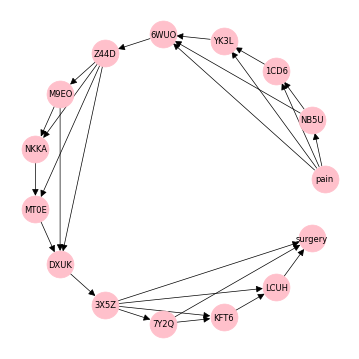


Context: Chronic disease LIH9XL sometimes requires surgical intervention, depending on genetics, patient history, vital signs, and lab results. The patient will experience significant pain (rated greater than or equal to 8/10) if they carry allele PSY9, a genetic marker for severe LIH9XL. If the patient self-reports significant pain or the patient has previously received surgery for I7D3, then vital NB5U will be elevated (greater than 2.08 mg/dL). If the patient self-reports significant pain or NB5U is elevated or the patient carries allele CCUF, then lab 1CD6 will be low (less than 3.01 mg/dL). If the patient self-reports significant pain or 1CD6 is low or the patient carries allele 45G4, then lab YK3L will be low (less than 0.46 mg/dL). If the patient self-reports significant pain or NB5U is elevated or YK3L is low or the patient carries allele QTDY, then vital 6WUO will be low (less than 0.51 mg/dL). If 6WUO is low or the patient has previously received surgery for 0AHS, then vital

In [21]:
size = [5,2,5,2,5]
tg = ClinicalNotes(n_per_bcc = size, 
                   bcc_types = ["wheel"]*len(size))
context = tg.get_causal_context()
patient_history = tg.get_sample_context(n_extra_vars = 2)
print()
print("Context:", context)
print()
print("Patient history:", patient_history)
print()
print("- Global cause-effect pairs:", tg.get_global())
print("- Local cause-effect pairs:", tg.get_local())
print("- Compositions:", tg.get_compositions())
print("- Causal functions:", tg.causal_functions)

In [22]:
print(tg.exog_names)
print(tg.exog_true_binary)
print(tg.alleles_obs)
print(tg.fam_hist_obs)
print(tg.prev_surg_obs)

['PSY9', 'I7D3', 'CCUF', '45G4', 'QTDY', '0AHS', 'WEJX', 'OY8Y', '6E64', '769T', 'BOKG', 'APS0', 'CSWB', 'G0HI', '4M8Y']
[1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1]
['PSY9', 'CCUF', '45G4', 'QTDY', 'G0HI']
['WEJX']
['I7D3', 'OY8Y', '4M8Y']


## Generate dataset

In [37]:
# x levels of graphical complexity (captured by BCC size).
# y tasks per graphical complexity level.
# z samples per task.
# w replicates per sample.
# = x*y*z*w subtasks.
graph_sizes = [[3,3]]
n_tasks_per_size = 3
n_samples_per_task = 1000
reps_per_sample = 5

df = dg.get_dataset(task_generator = ClinicalNotes,
                    graph_sizes = graph_sizes,
                    n_tasks_per_size = n_tasks_per_size,
                    n_samples_per_task = n_samples_per_task, 
                    reps_per_sample = reps_per_sample)

display(df)

,Task ID,Context ID,Sample ID,Nodes per BCC,Replicate ID,DAG adjacency matrix,DAG nodes,CCT adjacency matrix,CCT nodes,Exogenous variables,Bernoulli parameters,Global quantity,Local quantities,Compositions,Causal context,Sample context,Factual queries,Interventional queries (cause = True),Interventional queries (cause = False)
0,0.0.0,0,0,"[3, 3]",0,"[[0, 1, 1, 0, 0], [0, 0, 1, 0, 0], [0, 0, 0, 1...","[pain, 5IXX, CPNZ, EHGS, surgery]","[[0, 1, 1], [0, 0, 1], [0, 0, 0]]","[pain, CPNZ, surgery]","[GJL9, DT3B, LL80, CMDN, BK43]","[0.7, 0.5, 0.7, 0.7, 0.7]","(pain, surgery)","[(pain, CPNZ), (CPNZ, surgery)]","[[(pain, CPNZ), (CPNZ, surgery)]]",Chronic disease R9ESWH sometimes requires surg...,"Now, we will review the history and physical n...",{'surgery': {'Prompt': 'Given these history an...,"{('pain', 'surgery'): {'Prompt': 'Now suppose ...","{('pain', 'surgery'): {'Prompt': 'Now suppose ..."
1,0.0.1,0,0,"[3, 3]",1,"[[0, 1, 1, 0, 0], [0, 0, 1, 0, 0], [0, 0, 0, 1...","[pain, 5IXX, CPNZ, EHGS, surgery]","[[0, 1, 1], [0, 0, 1], [0, 0, 0]]","[pain, CPNZ, surgery]","[GJL9, DT3B, LL80, CMDN, BK43]","[0.7, 0.5, 0.7, 0.7, 0.7]","(pain, surgery)","[(pain, CPNZ), (CPNZ, surgery)]","[[(pain, CPNZ), (CPNZ, surgery)]]",Chronic disease R9ESWH sometimes requires surg...,"Now, we will review the history and physical n...",{'surgery': {'Prompt': 'Given these history an...,"{('pain', 'surgery'): {'Prompt': 'Now suppose ...","{('pain', 'surgery'): {'Prompt': 'Now suppose ..."
2,0.0.2,0,0,"[3, 3]",2,"[[0, 1, 1, 0, 0], [0, 0, 1, 0, 0], [0, 0, 0, 1...","[pain, 5IXX, CPNZ, EHGS, surgery]","[[0, 1, 1], [0, 0, 1], [0, 0, 0]]","[pain, CPNZ, surgery]","[GJL9, DT3B, LL80, CMDN, BK43]","[0.7, 0.5, 0.7, 0.7, 0.7]","(pain, surgery)","[(pain, CPNZ), (CPNZ, surgery)]","[[(pain, CPNZ), (CPNZ, surgery)]]",Chronic disease R9ESWH sometimes requires surg...,"Now, we will review the history and physical n...",{'surgery': {'Prompt': 'Given these history an...,"{('pain', 'surgery'): {'Prompt': 'Now suppose ...","{('pain', 'surgery'): {'Prompt': 'Now suppose ..."
3,0.0.3,0,0,"[3, 3]",3,"[[0, 1, 1, 0, 0], [0, 0, 1, 0, 0], [0, 0, 0, 1...","[pain, 5IXX, CPNZ, EHGS, surgery]","[[0, 1, 1], [0, 0, 1], [0, 0, 0]]","[pain, CPNZ, surgery]","[GJL9, DT3B, LL80, CMDN, BK43]","[0.7, 0.5, 0.7, 0.7, 0.7]","(pain, surgery)","[(pain, CPNZ), (CPNZ, surgery)]","[[(pain, CPNZ), (CPNZ, surgery)]]",Chronic disease R9ESWH sometimes requires surg...,"Now, we will review the history and physical n...",{'surgery': {'Prompt': 'Given these history an...,"{('pain', 'surgery'): {'Prompt': 'Now suppose ...","{('pain', 'surgery'): {'Prompt': 'Now suppose ..."
4,0.0.4,0,0,"[3, 3]",4,"[[0, 1, 1, 0, 0], [0, 0, 1, 0, 0], [0, 0, 0, 1...","[pain, 5IXX, CPNZ, EHGS, surgery]","[[0, 1, 1], [0, 0, 1], [0, 0, 0]]","[pain, CPNZ, surgery]","[GJL9, DT3B, LL80, CMDN, BK43]","[0.7, 0.5, 0.7, 0.7, 0.7]","(pain, surgery)","[(pain, CPNZ), (CPNZ, surgery)]","[[(pain, CPNZ), (CPNZ, surgery)]]",Chronic disease R9ESWH sometimes requires surg...,"Now, we will review the history and physical n...",{'surgery': {'Prompt': 'Given these history an...,"{('pain', 'surgery'): {'Prompt': 'Now suppose ...","{('pain', 'surgery'): {'Prompt': 'Now suppose ..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14995,2.999.0,2,999,"[3, 3]",0,"[[0, 1, 1, 0, 0], [0, 0, 1, 0, 0], [0, 0, 0, 1...","[pain, QJ8B, LVW4, 4UE7, surgery]","[[0, 1, 1], [0, 0, 1], [0, 0, 0]]","[pain, LVW4, surgery]","[41Q7, VZT1, XGZU, 28RQ, DKQJ]","[0.6, 0.6, 0.8, 0.5, 0.6]","(pain, surgery)","[(pain, LVW4), (LVW4, surgery)]","[[(pain, LVW4), (LVW4, surgery)]]",Chronic disease CK8IJ0 sometimes requires surg...,"Now, we will review the history and physical n...",{'surgery': {'Prompt': 'Given these history an...,"{('pain', 'surgery'): {'Prompt': 'Now suppose ...","{('pain', 'surgery'): {'Prompt': 'Now suppose ..."
14996,2.999.1,2,999,"[3, 3]",1,"[[0, 1, 1, 0, 0], [0, 0, 1, 0, 0], [0, 0, 0, 1...","[pain, QJ8B, LVW4, 4UE7, surgery]","[[0, 1,

In [38]:
# Process prompts.
df_factual, df_cf = dg.process_prompts()
display(df_factual)
display(df_cf)

,Task ID,Context ID,Sample ID,Replicate ID,Nodes per BCC,Effect,Context,Question,True
0,0.0.0,0,0,0,"[3, 3]",surgery,Chronic disease R9ESWH sometimes requires surg...,"Given these history and physical notes, will t...",1
1,0.0.0,0,0,0,"[3, 3]",CPNZ,Chronic disease R9ESWH sometimes requires surg...,"Given these history and physical notes, will l...",1
2,0.0.1,0,0,1,"[3, 3]",surgery,Chronic disease R9ESWH sometimes requires surg...,"Given these history and physical notes, will t...",1
3,0.0.1,0,0,1,"[3, 3]",CPNZ,Chronic disease R9ESWH sometimes requires surg...,"Given these history and physical notes, will l...",1
4,0.0.2,0,0,2,"[3, 3]",surgery,Chronic disease R9ESWH sometimes requires surg...,"Given these history and physical notes, will t...",1
...,...,...,...,...,...,...,...,...,...
29995,2.999.2,2,999,2,"[3, 3]",LVW4,Chronic disease CK8IJ0 sometimes requires surg...,"Given these history and physical notes, will v...",0
29996,2.999.3,2,999,3,"[3, 3]",surgery,Chronic disease CK8IJ0 sometimes requires surg...,"Given these history and physical notes, will t...",0
29997,2.999.3,2,999,3,"[3, 3]",LVW4,Chronic disease CK8IJ0 sometimes requires surg...,"Given these history and physical notes, will v...",0
29998,2.999.4,2,999,4,"[3, 3]",surgery,Chronic disease CK8IJ0 sometimes requires surg...,"Given these history and physical notes, will t...",0


,Task ID,Context ID,Sample ID,Replicate ID,Nodes per BCC,Cause-effect pair,Cause,Effect,Context,Question (cause = True),True (cause = True),Question (cause = False),True (cause = False)
0,0.0.0,0,0,0,"[3, 3]","(pain, surgery)",pain,surgery,Chronic disease R9ESWH sometimes requires surg...,Now suppose that the patient will be in signif...,1,Now suppose that the patient will not be in pa...,0
1,0.0.0,0,0,0,"[3, 3]","(pain, CPNZ)",pain,CPNZ,Chronic disease R9ESWH sometimes requires surg...,Now suppose that the patient will be in signif...,1,Now suppose that the patient will not be in pa...,0
2,0.0.0,0,0,0,"[3, 3]","(CPNZ, surgery)",CPNZ,surgery,Chronic disease R9ESWH sometimes requires surg...,Now suppose that lab CPNZ will be elevated reg...,1,Now suppose that lab CPNZ will not be elevated...,0
3,0.0.1,0,0,1,"[3, 3]","(pain, surgery)",pain,surgery,Chronic disease R9ESWH sometimes requires surg...,Now suppose that the patient will be in signif...,1,Now suppose that the patient will not be in pa...,0
4,0.0.1,0,0,1,"[3, 3]","(pain, CPNZ)",pain,CPNZ,Chronic disease R9ESWH sometimes requires surg...,Now suppose that the patient will be in signif...,1,Now suppose that the patient will not be in pa...,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
44995,2.999.3,2,999,3,"[3, 3]","(pain, LVW4)",pain,LVW4,Chronic disease CK8IJ0 sometimes requires surg...,Now suppose that the patient will be in signif...,1,Now suppose that the patient will not be in pa...,0
44996,2.999.3,2,999,3,"[3, 3]","(LVW4, surgery)",LVW4,surgery,Chronic disease CK8IJ0 sometimes requires surg...,Now suppose that vital LVW4 will be elevated r...,0,Now suppose that vital LVW4 will not be elevat...,0
44997,2.999.4,2,999,4,"[3, 3]","(pain, surgery)",pain,surgery,Chronic disease CK8IJ0 sometimes requires surg...,Now suppose that the patient will be in signif...,0,Now suppose that the patient will not be in pa...,0
44998,2.999.4,2,999,4,"[3, 3]","(pain, LVW4)",pain,LVW4,Chronic disease CK8IJ0 sometimes requires surg...,Now suppose that the patient will be in signif...,1,Now suppose that the patient will not be in pa...,0


In [39]:
pns_dict = dg.get_pns_dict(verbose = True)
pns_dict

-- PNS = 0.109 | ATE = 0.10899999999999999 --
-- PNS = 0.149 | ATE = 0.14900000000000002 --
-- PNS = 0.706 | ATE = 0.706 --
-- PNS = 0.052 | ATE = 0.051999999999999935 --
-- PNS = 0.089 | ATE = 0.08899999999999997 --
-- PNS = 0.588 | ATE = 0.588 --
-- PNS = 0.054 | ATE = 0.05399999999999994 --
-- PNS = 0.094 | ATE = 0.09399999999999997 --
-- PNS = 0.6 | ATE = 0.6 --


{0: {"('pain', 'surgery')": 0.109,
  "('pain', 'CPNZ')": 0.149,
  "('CPNZ', 'surgery')": 0.706,
  "[('pain', 'CPNZ'), ('CPNZ', 'surgery')]": 0.105194},
 1: {"('pain', 'surgery')": 0.052,
  "('pain', 'MYI7')": 0.089,
  "('MYI7', 'surgery')": 0.588,
  "[('pain', 'MYI7'), ('MYI7', 'surgery')]": 0.052332},
 2: {"('pain', 'surgery')": 0.054,
  "('pain', 'LVW4')": 0.094,
  "('LVW4', 'surgery')": 0.6,
  "[('pain', 'LVW4'), ('LVW4', 'surgery')]": 0.0564}}

In [40]:
threshold_dict = dg.get_internal_consistency_thresholds(multiplier = 1.25)
threshold_dict

{0: {"[('pain', 'CPNZ'), ('CPNZ', 'surgery')]": 0.04364678899082573},
 1: {"[('pain', 'MYI7'), ('MYI7', 'surgery')]": 0.007980769230769206},
 2: {"[('pain', 'LVW4'), ('LVW4', 'surgery')]": 0.05555555555555554}}

In [41]:
# Test save and load with numpy.
np.save("clinical_notes_threshold_dict.npy", threshold_dict) 
read_dictionary = np.load("clinical_notes_threshold_dict.npy",
                          allow_pickle = "TRUE").item()
display(read_dictionary)

{0: {"[('pain', 'CPNZ'), ('CPNZ', 'surgery')]": 0.04364678899082573},
 1: {"[('pain', 'MYI7'), ('MYI7', 'surgery')]": 0.007980769230769206},
 2: {"[('pain', 'LVW4'), ('LVW4', 'surgery')]": 0.05555555555555554}}

In [42]:
df_cf[df_cf["Context ID"] == 0]

,Task ID,Context ID,Sample ID,Replicate ID,Nodes per BCC,Cause-effect pair,Cause,Effect,Context,Question (cause = True),True (cause = True),Question (cause = False),True (cause = False)
0,0.0.0,0,0,0,"[3, 3]","(pain, surgery)",pain,surgery,Chronic disease R9ESWH sometimes requires surg...,Now suppose that the patient will be in signif...,1,Now suppose that the patient will not be in pa...,0
1,0.0.0,0,0,0,"[3, 3]","(pain, CPNZ)",pain,CPNZ,Chronic disease R9ESWH sometimes requires surg...,Now suppose that the patient will be in signif...,1,Now suppose that the patient will not be in pa...,0
2,0.0.0,0,0,0,"[3, 3]","(CPNZ, surgery)",CPNZ,surgery,Chronic disease R9ESWH sometimes requires surg...,Now suppose that lab CPNZ will be elevated reg...,1,Now suppose that lab CPNZ will not be elevated...,0
3,0.0.1,0,0,1,"[3, 3]","(pain, surgery)",pain,surgery,Chronic disease R9ESWH sometimes requires surg...,Now suppose that the patient will be in signif...,1,Now suppose that the patient will not be in pa...,0
4,0.0.1,0,0,1,"[3, 3]","(pain, CPNZ)",pain,CPNZ,Chronic disease R9ESWH sometimes requires surg...,Now suppose that the patient will be in signif...,1,Now suppose that the patient will not be in pa...,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
14995,0.999.3,0,999,3,"[3, 3]","(pain, CPNZ)",pain,CPNZ,Chronic disease R9ESWH sometimes requires surg...,Now suppose that the patient will be in signif...,1,Now suppose that the patient will not be in pa...,0
14996,0.999.3,0,999,3,"[3, 3]","(CPNZ, surgery)",CPNZ,surgery,Chronic disease R9ESWH sometimes requires surg...,Now suppose that lab CPNZ will be elevated reg...,0,Now suppose that lab CPNZ will not be elevated...,0
14997,0.999.4,0,999,4,"[3, 3]","(pain, surgery)",pain,surgery,Chronic disease R9ESWH sometimes requires surg...,Now suppose that the patient will be in signif...,0,Now suppose that the patient will not be in pa...,0
14998,0.999.4,0,999,4,"[3, 3]","(pain, CPNZ)",pain,CPNZ,Chronic disease R9ESWH sometimes requires surg...,Now suppose that the patient will be in signif...,1,Now suppose that the patient will not be in pa...,0


In [43]:
df_cf[(df_cf["Context ID"] == 0) & (df_cf["Cause-effect pair"] == ("pain", "surgery"))]

,Task ID,Context ID,Sample ID,Replicate ID,Nodes per BCC,Cause-effect pair,Cause,Effect,Context,Question (cause = True),True (cause = True),Question (cause = False),True (cause = False)
0,0.0.0,0,0,0,"[3, 3]","(pain, surgery)",pain,surgery,Chronic disease R9ESWH sometimes requires surg...,Now suppose that the patient will be in signif...,1,Now suppose that the patient will not be in pa...,0
3,0.0.1,0,0,1,"[3, 3]","(pain, surgery)",pain,surgery,Chronic disease R9ESWH sometimes requires surg...,Now suppose that the patient will be in signif...,1,Now suppose that the patient will not be in pa...,0
6,0.0.2,0,0,2,"[3, 3]","(pain, surgery)",pain,surgery,Chronic disease R9ESWH sometimes requires surg...,Now suppose that the patient will be in signif...,1,Now suppose that the patient will not be in pa...,0
9,0.0.3,0,0,3,"[3, 3]","(pain, surgery)",pain,surgery,Chronic disease R9ESWH sometimes requires surg...,Now suppose that the patient will be in signif...,1,Now suppose that the patient will not be in pa...,0
12,0.0.4,0,0,4,"[3, 3]","(pain, surgery)",pain,surgery,Chronic disease R9ESWH sometimes requires surg...,Now suppose that the patient will be in signif...,1,Now suppose that the patient will not be in pa...,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
14985,0.999.0,0,999,0,"[3, 3]","(pain, surgery)",pain,surgery,Chronic disease R9ESWH sometimes requires surg...,Now suppose that the patient will be in signif...,0,Now suppose that the patient will not be in pa...,0
14988,0.999.1,0,999,1,"[3, 3]","(pain, surgery)",pain,surgery,Chronic disease R9ESWH sometimes requires surg...,Now suppose that the patient will be in signif...,0,Now suppose that the patient will not be in pa...,0
14991,0.999.2,0,999,2,"[3, 3]","(pain, surgery)",pain,surgery,Chronic disease R9ESWH sometimes requires surg...,Now suppose that the patient will be in signif...,0,Now suppose that the patient will not be in pa...,0
14994,0.999.3,0,999,3,"[3, 3]","(pain, surgery)",pain,surgery,Chronic disease R9ESWH sometimes requires surg...,Now suppose that the patient will be in signif...,0,Now suppose that the patient will not be in pa...,0


In [44]:
test = df_cf[(df_cf["Context ID"] == 1) & (df_cf["Cause-effect pair"] == ("pain", "surgery"))]
test = test[["Context", "Question (cause = True)", "True (cause = True)"]]
test.head()

,Context,Question (cause = True),True (cause = True)
15000,Chronic disease CFFRJ3 sometimes requires surg...,Now suppose that the patient will be in signif...,0
15003,Chronic disease CFFRJ3 sometimes requires surg...,Now suppose that the patient will be in signif...,0
15006,Chronic disease CFFRJ3 sometimes requires surg...,Now suppose that the patient will be in signif...,0
15009,Chronic disease CFFRJ3 sometimes requires surg...,Now suppose that the patient will be in signif...,0
15012,Chronic disease CFFRJ3 sometimes requires surg...,Now suppose that the patient will be in signif...,0


In [45]:
for col in test.columns:
    print(test[col][15000])
    print()

Chronic disease CFFRJ3 sometimes requires surgical intervention, depending on genetics, patient history, vital signs, and lab results. The patient will experience significant pain (rated greater than or equal to 9/10) if they carry allele NJIL, a genetic marker for severe CFFRJ3. If the patient self-reports significant pain or the patient has a family history of 2OQB, then vital UEHJ will be elevated (greater than 0.24 mg/dL). If the patient self-reports significant pain or UEHJ is elevated or the patient carries allele 8LG6, then vital MYI7 will be low (less than 1.07 mg/dL). If MYI7 is low or the patient has previously received surgery for QCEJ, then lab TJIC will be elevated (greater than 2.88 mg/dL). If MYI7 is low and TJIC is elevated and the patient has a family history of 1Z83, then the surgeon will recommend surgery. Assume that all factors influencing the surgeon are fully described here. Now, we will review the history and physical notes for patient Stephanie Carpenter. Histo

In [46]:
test = df_cf[(df_cf["Context ID"] == 1) & (df_cf["Cause-effect pair"] == ("pain", "surgery"))]
test = test[["Context", "Question (cause = False)", "True (cause = False)"]]
test.head()

,Context,Question (cause = False),True (cause = False)
15000,Chronic disease CFFRJ3 sometimes requires surg...,Now suppose that the patient will not be in pa...,0
15003,Chronic disease CFFRJ3 sometimes requires surg...,Now suppose that the patient will not be in pa...,0
15006,Chronic disease CFFRJ3 sometimes requires surg...,Now suppose that the patient will not be in pa...,0
15009,Chronic disease CFFRJ3 sometimes requires surg...,Now suppose that the patient will not be in pa...,0
15012,Chronic disease CFFRJ3 sometimes requires surg...,Now suppose that the patient will not be in pa...,0


In [48]:
for col in test.columns:
    print(test[col][15000])
    print()

Chronic disease CFFRJ3 sometimes requires surgical intervention, depending on genetics, patient history, vital signs, and lab results. The patient will experience significant pain (rated greater than or equal to 9/10) if they carry allele NJIL, a genetic marker for severe CFFRJ3. If the patient self-reports significant pain or the patient has a family history of 2OQB, then vital UEHJ will be elevated (greater than 0.24 mg/dL). If the patient self-reports significant pain or UEHJ is elevated or the patient carries allele 8LG6, then vital MYI7 will be low (less than 1.07 mg/dL). If MYI7 is low or the patient has previously received surgery for QCEJ, then lab TJIC will be elevated (greater than 2.88 mg/dL). If MYI7 is low and TJIC is elevated and the patient has a family history of 1Z83, then the surgeon will recommend surgery. Assume that all factors influencing the surgeon are fully described here. Now, we will review the history and physical notes for patient Stephanie Carpenter. Histo

## End of document